In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

### 5-Fold Cross-Validation Accuracy: 0.9596 (+/- 0.0363)

### LOGISTIC REGRESSION COEFFICIENTS (Sorted)
                                      Feature  Coefficient
13                                    TechLev     1.919062
15                                   InnoCont     1.623294
11                                      AIUse     1.492410
17                                  PerfScore     1.264967
16                                 TrainHours     1.238124
12                       SpecialProjectsCount     1.015185
7                                      AIConf     0.935656
9                                    Feedback     0.866259
4                                    ProjColl     0.547960
14                                     ManPos     0.475384
8                                     PsySafe     0.418424
27                             RaceDesc_White     0.392563
31                   RecruitmentSource_Indeed     0.376775
22                        MaritalDesc_Widowed     0.275587
10        

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_93692/4069584442.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


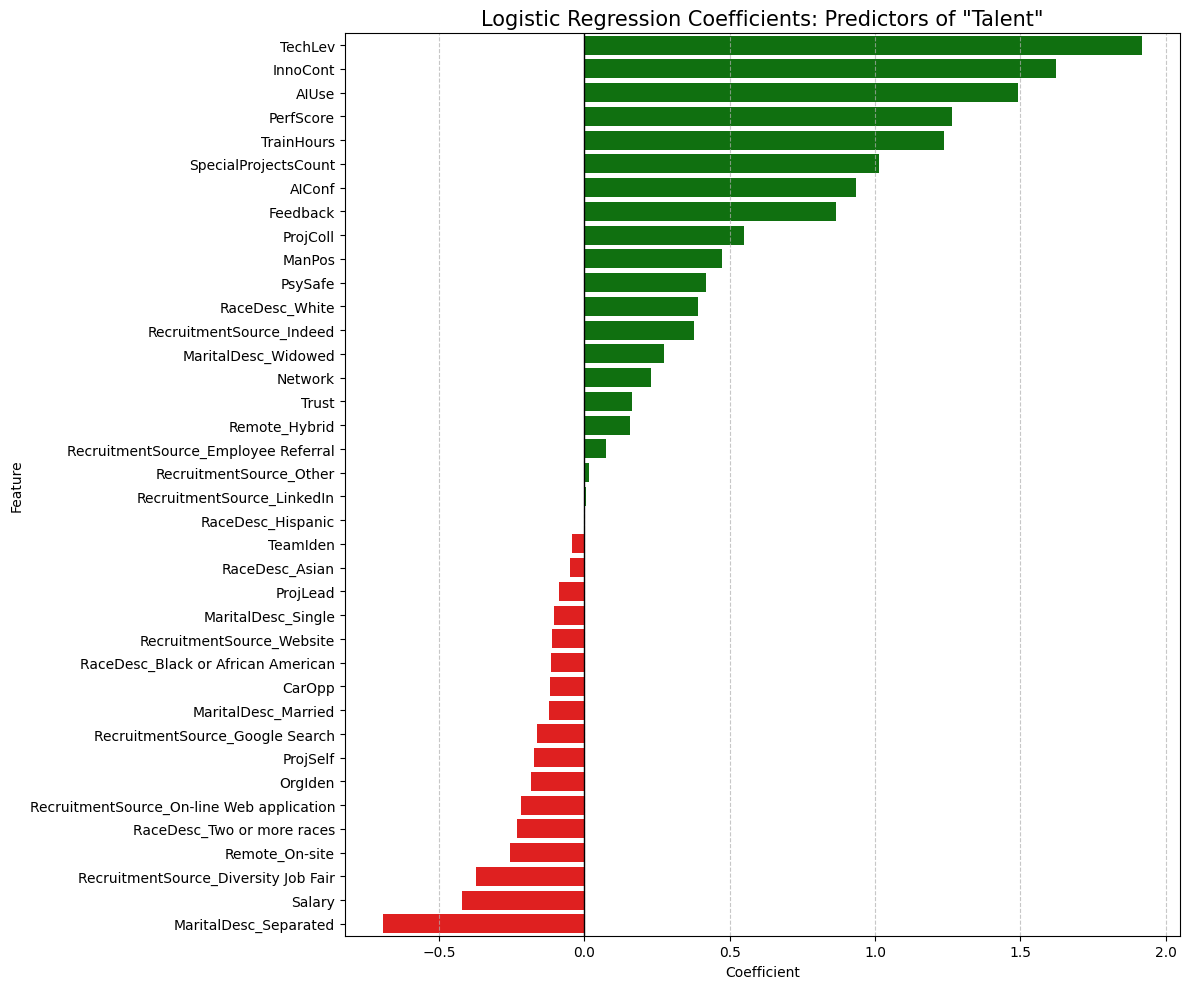

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Define features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

# 2. Data Preparation
# Target: is_talent
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_talent']

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

# 4. Build Logistic Regression Pipeline
# Added StandardScaler: essential for Logistic Regression to compare coefficients fairly
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])

# 5. Cross-Validation (CV=5)
# This tests the model's stability on 5 different folds of the training data
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)

# 6. Train the Model
model_pipeline.fit(X_train, y_train)

# 7. Extract and Order Coefficients
# We access the classifier from the pipeline to get weights
coefs = model_pipeline.named_steps['classifier'].coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

# --- FINAL OUTPUTS ---

print(f"### 5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n### LOGISTIC REGRESSION COEFFICIENTS (Sorted)")
print(coef_df)

# Evaluation on separate Test Set
y_test_pred = model_pipeline.predict(X_test)
print("\n### TEST SET CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

# 8. Visualization of Coefficients
plt.figure(figsize=(12, 10))
# Using a diverging color palette to highlight positive vs negative
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

plt.title('Logistic Regression Coefficients: Predictors of "Talent"', fontsize=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Add a center line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5-Fold CV Accuracy: 0.8643

### TOP PREDICTORS OF TURNOVER (Positive = Higher Risk of Leaving)
                                      Feature  Coefficient
17                                  PerfScore     0.835498
15                                   InnoCont     0.608995
11                                      AIUse     0.485219
33  RecruitmentSource_On-line Web application     0.420763
37                             Remote_On-site     0.398290
36                              Remote_Hybrid     0.344813
10                                    Network     0.329143
16                                 TrainHours     0.318287
30            RecruitmentSource_Google Search     0.233437
27                             RaceDesc_White     0.205264

### TOP 5 ACTIVE EMPLOYEES AT RISK
     Employee_Index  Flight_Risk_Probability
15               23                 0.988888
50               69                 0.970494
195             288                 0.954268
80              111                 

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_93692/895728963.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)


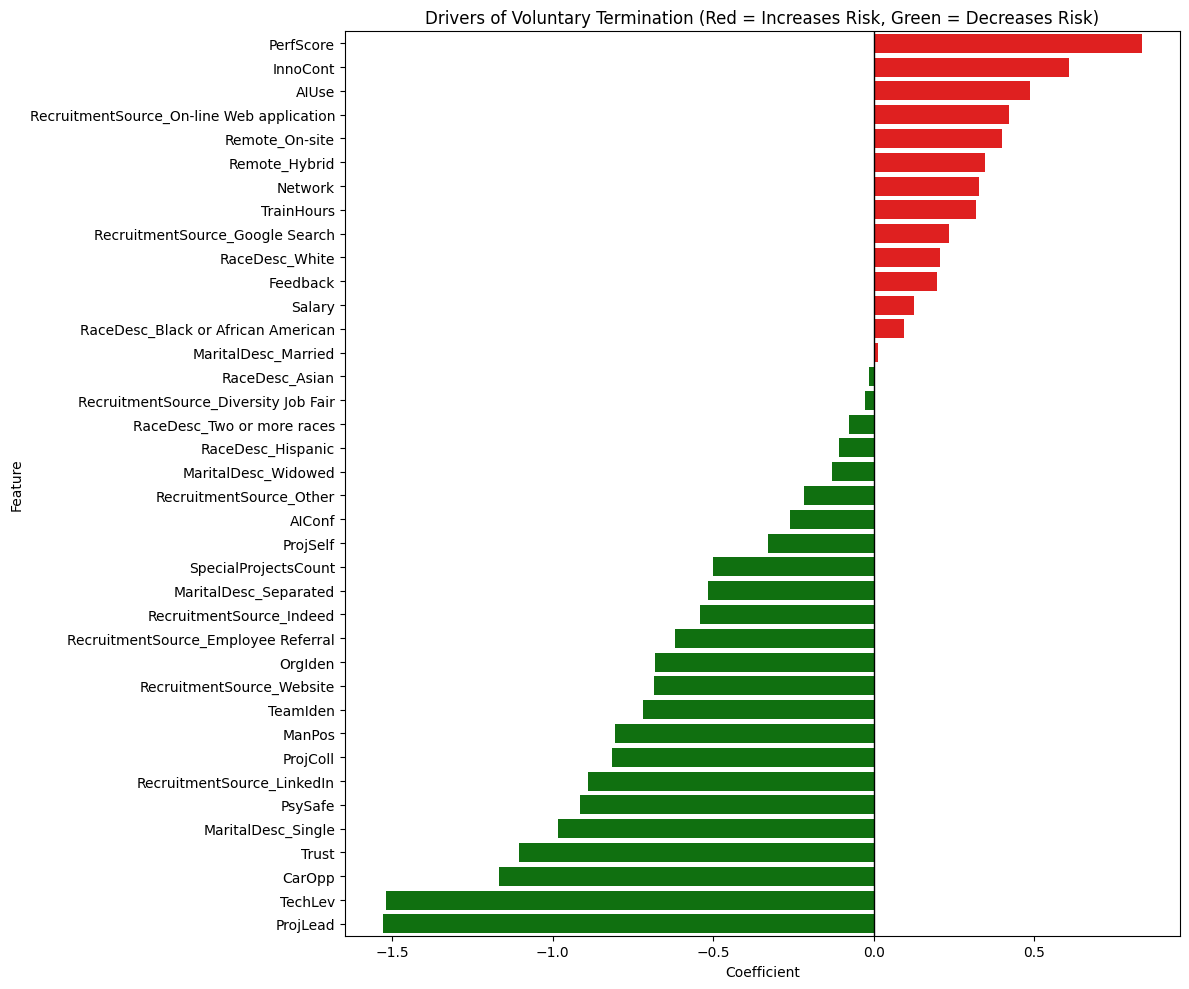

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Filter Data and Map Binary Target
# We only want Active and Voluntarily Terminated
target_map = {'Active': 0, 'Voluntarily Terminated': 1}
df_filtered = df[df['EmploymentStatus'].isin(target_map.keys())].copy()
df_filtered['Target'] = df_filtered['EmploymentStatus'].map(target_map)

# 2. Define Features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered['Target']

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Pipeline (StandardScaler is mandatory for Logistic Regression)
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# 5. 5-Fold Cross-Validation
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)

# 6. Train the Model
model_pipeline.fit(X_train, y_train)

# 7. Coefficient Analysis
coefs = model_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

# 8. Calculate Probabilities for ALL currently Active users
active_users = X[y == 0]
# Column 1 corresponds to class '1' (Voluntarily Terminated)
flight_risk_probs = model_pipeline.predict_proba(active_users)[:, 1]

# --- OUTPUTS ---

print(f"### 5-Fold CV Accuracy: {cv_scores.mean():.4f}")

print("\n### TOP PREDICTORS OF TURNOVER (Positive = Higher Risk of Leaving)")
print(importance_df.head(10))

# Displaying a few risk scores
risk_table = pd.DataFrame({
    'Employee_Index': active_users.index,
    'Flight_Risk_Probability': flight_risk_probs
}).sort_values(by='Flight_Risk_Probability', ascending=False)

print("\n### TOP 5 ACTIVE EMPLOYEES AT RISK")
print(risk_table.head(5))

# 9. Visualization
plt.figure(figsize=(12, 10))
colors = ['red' if x > 0 else 'green' for x in importance_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)
plt.title('Drivers of Voluntary Termination (Red = Increases Risk, Green = Decreases Risk)')
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

### 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET)
Mean Accuracy:  0.8509
Mean Precision: 0.7288
Mean Recall:    0.8066
Mean F1-Score:  0.7636


/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_93692/1090593668.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)


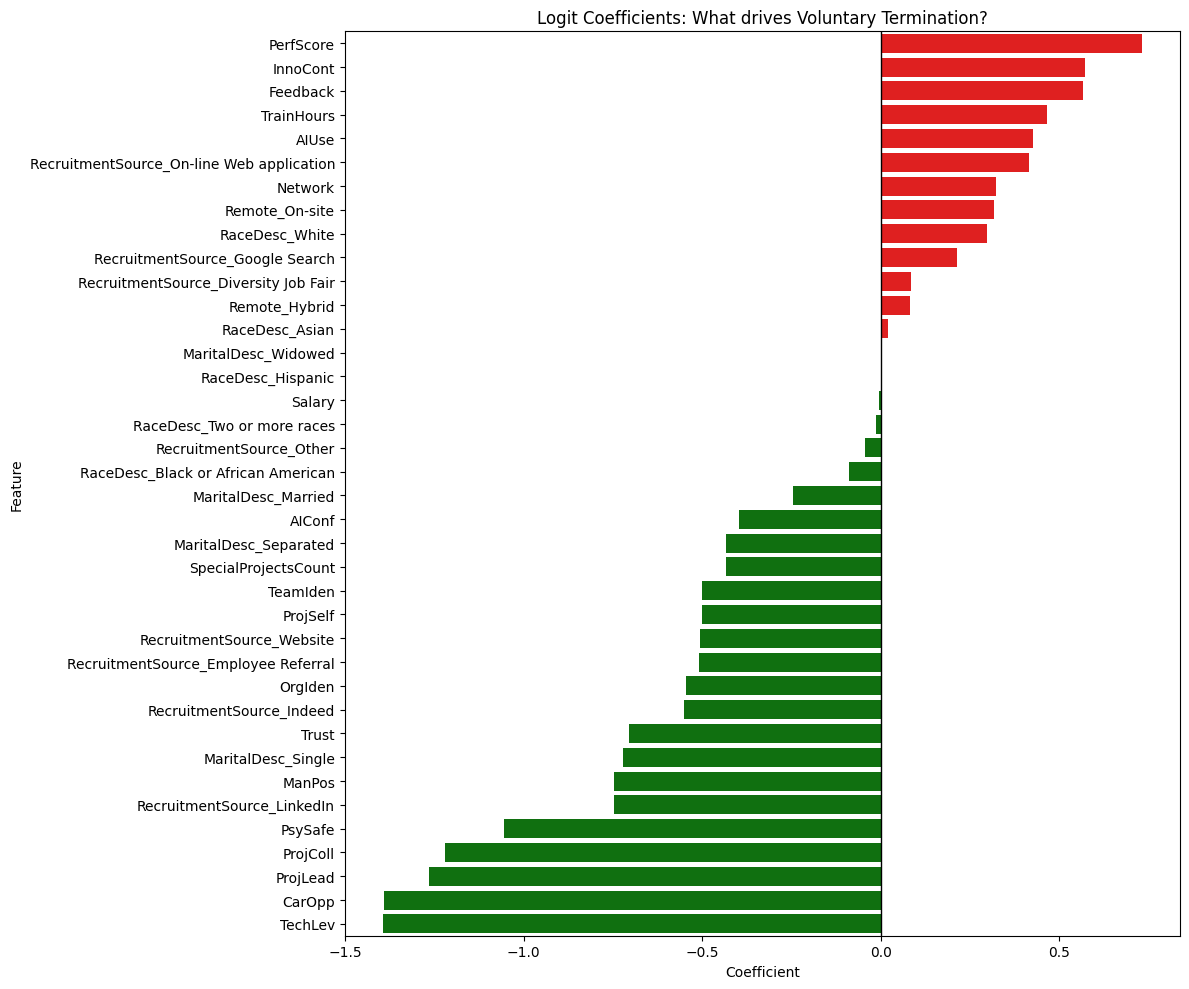


### RISK ASSESSMENT: THE 20 LEFT-OUT EMPLOYEES
            Employee_Name           Actual_Status  Leaving_Probability
296  Wallace, Courtney  E  Voluntarily Terminated             0.987451
49    Cloninger, Jennifer  Voluntarily Terminated             0.927797
50            Close, Phil  Voluntarily Terminated             0.902718
168     Linares, Marilyn   Voluntarily Terminated             0.775403
235     Robinson, Alain    Voluntarily Terminated             0.672328
212      Patronick, Lucas  Voluntarily Terminated             0.661209
148       Keatts, Kramer                   Active             0.428180
60         Daneault, Lynn                  Active             0.226937
187       Miller, Brannon                  Active             0.133720
141      Jeannite, Tayana                  Active             0.092208
106     Girifalco, Evelyn                  Active             0.074752
90    Fernandes, Nilson                    Active             0.035895
100          Garcia, Raul    

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Filter Data and Map Binary Target (0: Active, 1: Voluntarily Terminated)
target_map = {'Active': 0, 'Voluntarily Terminated': 1}
df_filtered = df[df['EmploymentStatus'].isin(target_map.keys())].copy()
df_filtered['Target'] = df_filtered['EmploymentStatus'].map(target_map)

# 2. Define Features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered['Target']

# 3. Leave exactly 20 people out for the test set
test_count = 20
test_ratio = test_count / len(df_filtered)

# Change random_state to None for true randomness every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=None, stratify=y
)

# 4. Build Pipeline
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# 5. 5-Fold Cross-Validation on Training Set (Metrics: Accuracy, Recall, Precision, F1)
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(model_pipeline, X_train, y_train, cv=5, scoring=scoring)

# 6. Train the Model on the full training set
model_pipeline.fit(X_train, y_train)

# 7. Output CV Metrics
print("### 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET)")
print(f"Mean Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1-Score:  {cv_results['test_f1'].mean():.4f}")

# 8. Coefficient Analysis & Visualization
coefs = model_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 10))
colors = ['red' if x > 0 else 'green' for x in importance_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)
plt.title('Logit Coefficients: What drives Voluntary Termination?')
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

# 9. Apply model to the 20 left-out people
# Probability of leaving (Class 1)
test_probs = model_pipeline.predict_proba(X_test)[:, 1]

# Create final dataframe for the 20 test subjects
# We map the numeric target back to original labels for readability
risk_report_20 = pd.DataFrame({
    'Actual_Status': y_test.map({0: 'Active', 1: 'Voluntarily Terminated'}).values,
    'Leaving_Probability': test_probs
}, index=X_test.index)

# Add Employee Name if available
if 'Employee.Name' in df.columns:
    risk_report_20.insert(0, 'Employee_Name', df.loc[X_test.index, 'Employee.Name'].values)

print("\n### RISK ASSESSMENT: THE 20 LEFT-OUT EMPLOYEES")
print(risk_report_20.sort_values('Leaving_Probability', ascending=False))

# Optional: Performance on those 20 people
print("\n### CLASSIFICATION REPORT FOR THE 20 TEST EMPLOYEES")
y_test_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))

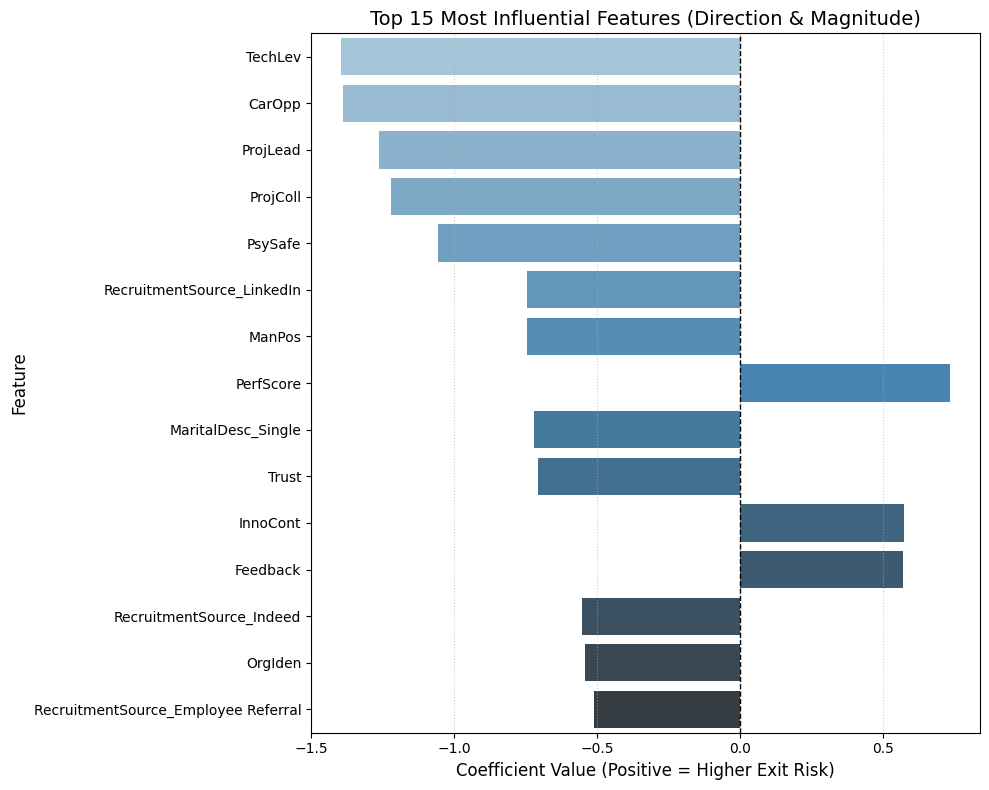

In [10]:
# 1. Calculate Magnitude and Sort
importance_df['Magnitude'] = importance_df['Coefficient'].abs()
top_15_features = importance_df.nlargest(15, 'Magnitude')

# 2. Plotting
plt.figure(figsize=(10, 8))

# Using a sequential blue palette, sorted by magnitude
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=top_15_features, 
    palette='Blues_d',  # Dark to light blue palette
    hue='Feature',      # Keeps current seaborn versions happy
    legend=False
)

# 3. Aesthetics
plt.title('Top 15 Most Influential Features (Direction & Magnitude)', fontsize=14)
plt.xlabel('Coefficient Value (Positive = Higher Exit Risk)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', lw=1, linestyle='--') # Reference line at zero
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

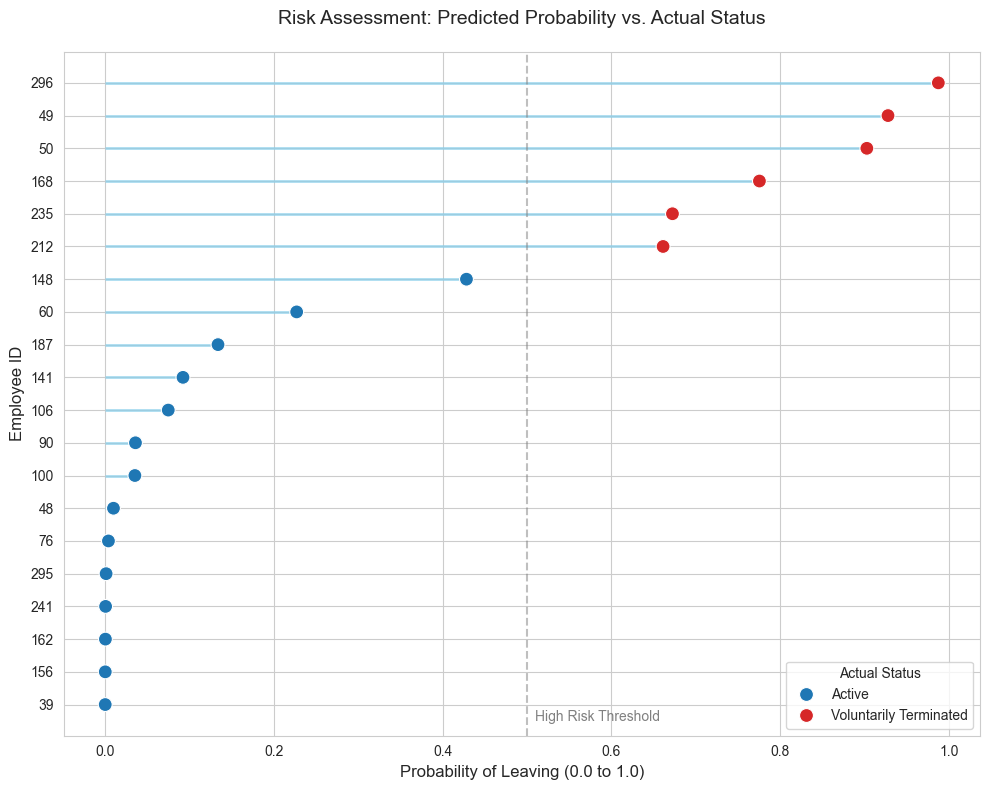

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data (assuming risk_report_20 is already created)
# Sort by probability so the chart is easy to read
plot_df = risk_report_20.sort_values('Leaving_Probability', ascending=True).reset_index()
plot_df.rename(columns={'index': 'Employee_ID'}, inplace=True)

# 2. Set up the figure
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 3. Create the "Lollipop" chart
# Plot the lines
plt.hlines(y=range(len(plot_df)), xmin=0, xmax=plot_df['Leaving_Probability'], 
           color='skyblue', alpha=0.7, linewidth=2)

# Plot the dots, colored by Actual Status
# Blue = Active, Orange/Red = Voluntarily Terminated
ax = sns.scatterplot(x='Leaving_Probability', y=range(len(plot_df)), 
                     hue='Actual_Status', data=plot_df, 
                     palette={'Active': '#1f77b4', 'Voluntarily Terminated': '#d62728'}, 
                     s=100, zorder=3)

# 4. Clean up labels and axes
plt.yticks(range(len(plot_df)), plot_df['Employee_ID'])
plt.title('Risk Assessment: Predicted Probability vs. Actual Status', fontsize=14, pad=20)
plt.xlabel('Probability of Leaving (0.0 to 1.0)', fontsize=12)
plt.ylabel('Employee ID', fontsize=12)
plt.legend(title='Actual Status', loc='lower right')

# Add a "Risk Threshold" line at 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.text(0.51, -0.5, 'High Risk Threshold', color='gray', fontsize=10)

plt.tight_layout()
plt.show()

### RISK ASSESSMENT: 57 ACTIVE TALENT EMPLOYEES
Employee_ID  Leaving_Probability
        254             0.612445
        245             0.337331
         35             0.291613
        257             0.246153
        145             0.226278
        197             0.193554
        172             0.107429
        282             0.101718
        208             0.079530
        164             0.079186
        308             0.077500
        274             0.063435
         51             0.050751
        228             0.048605
        192             0.047861
        193             0.035410
        252             0.033363
         98             0.033324
         22             0.025744
          7             0.019354
        140             0.015418
          0             0.012601
        120             0.012433
        275             0.011804
         59             0.010796
         48             0.009819
        170             0.009449
        299             0.00

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_93692/849672930.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


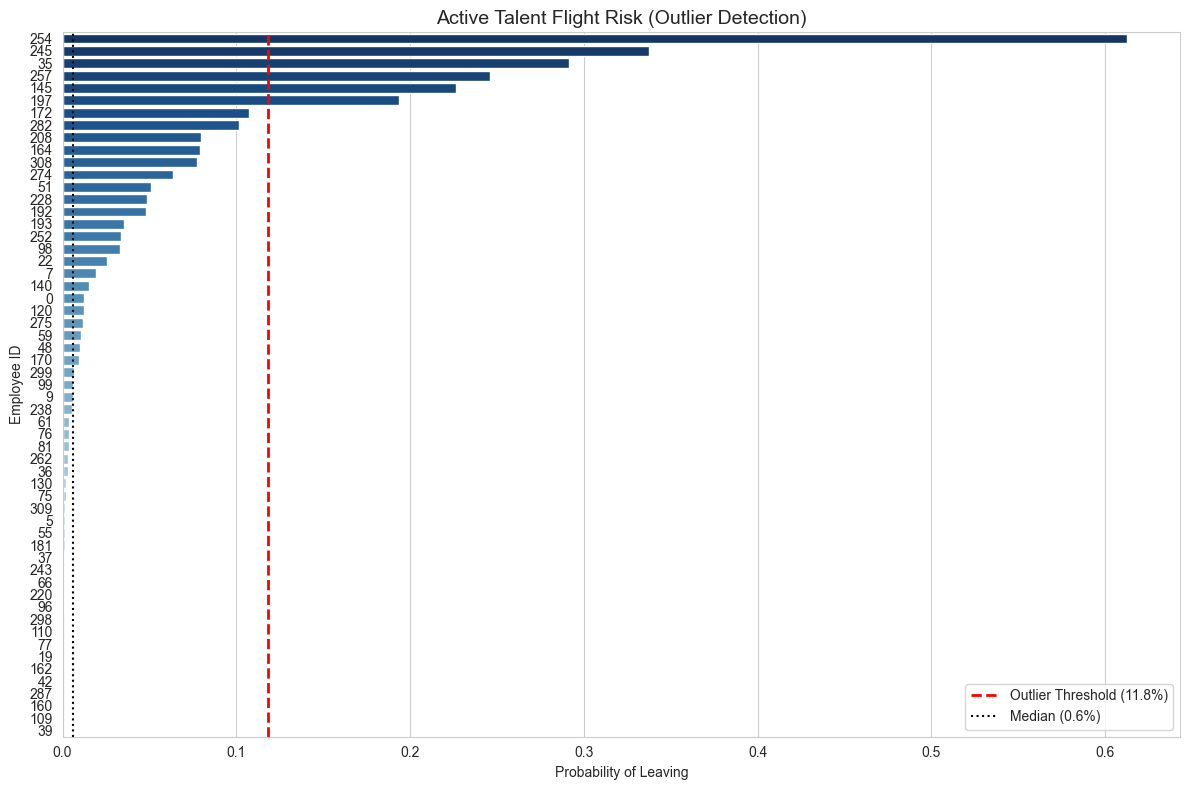

In [18]:
# 1. Filter for ACTIVE Talent only
active_talent_df = df[(df['is_talent'] == 1) & (df['EmploymentStatus'] == 'Active')].copy()

# 2. Prepare features (ensuring alignment with training columns)
X_active = pd.get_dummies(active_talent_df[features], drop_first=True)
X_active = X_active.reindex(columns=X.columns, fill_value=0)

# 3. Predict Probabilities
active_probs = model_pipeline.predict_proba(X_active)[:, 1]

# 4. Create the Active Talent Risk Report
active_risk_report = pd.DataFrame({
    'Employee_ID': active_talent_df.index.astype(str), # Use ID as string for plotting
    'Leaving_Probability': active_probs
})

# 5. Calculate Outlier Threshold (Boxplot Method: Q3 + 1.5*IQR)
Q1 = active_risk_report['Leaving_Probability'].quantile(0.25)
Q3 = active_risk_report['Leaving_Probability'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + (1.5 * IQR)

# 6. Output Summary Statistics
print(f"### RISK ASSESSMENT: {len(active_risk_report)} ACTIVE TALENT EMPLOYEES")
print(active_risk_report.sort_values('Leaving_Probability', ascending=False).to_string(index=False))

print("\n" + "="*45)
print(f"Q1 (25th Percentile):    {Q1:.2%}")
print(f"Q3 (75th Percentile):    {Q3:.2%}")
print(f"IQR:                     {IQR:.2%}")
print(f"OUTLIER THRESHOLD:       {outlier_threshold:.2%}") 
print("="*45)

# 7. Plotting the results
plt.figure(figsize=(12, 8))

# Sort by probability
plot_data = active_risk_report.sort_values('Leaving_Probability', ascending=False)

# Bar plot with ID on Y-axis and Blue palette
sns.barplot(
    x='Leaving_Probability', 
    y='Employee_ID', 
    data=plot_data, 
    palette='Blues_r'
)

# Add Boxplot Outlier Threshold line
plt.axvline(outlier_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Outlier Threshold ({outlier_threshold:.1%})')

# Add Median line for context
median_val = active_risk_report['Leaving_Probability'].median()
plt.axvline(median_val, color='black', linestyle=':', label=f'Median ({median_val:.1%})')

plt.title('Active Talent Flight Risk (Outlier Detection)', fontsize=14)
plt.xlabel('Probability of Leaving')
plt.ylabel('Employee ID')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_93692/3218864182.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


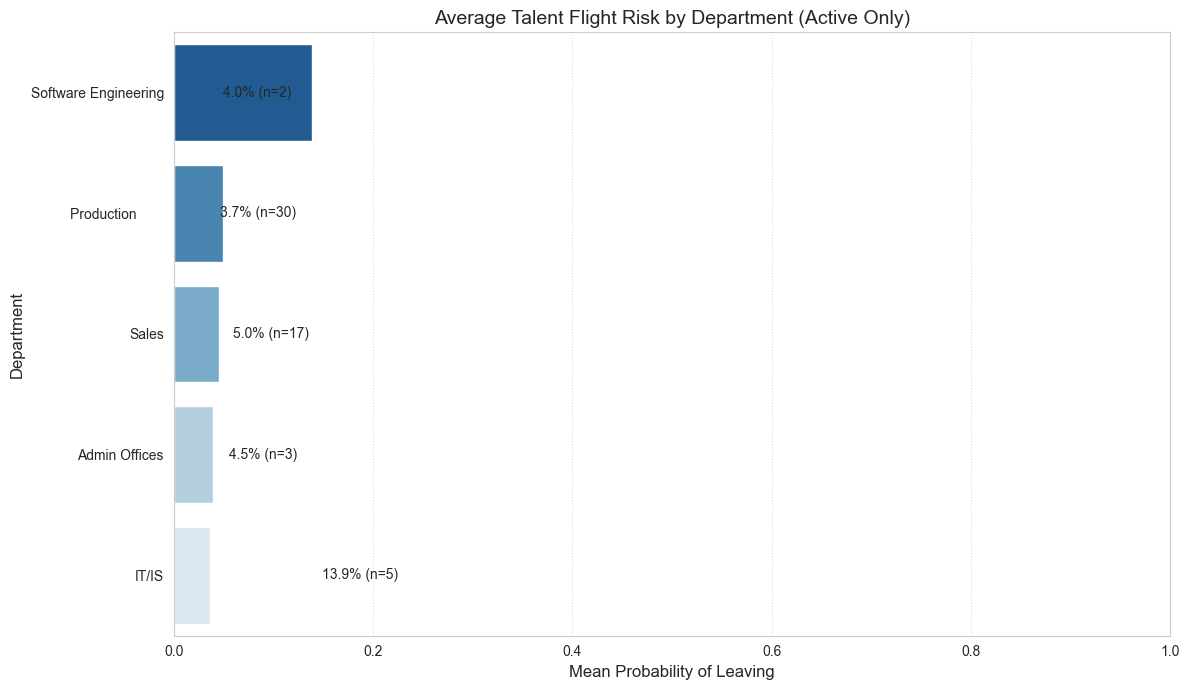

### TALENT RISK SUMMARY BY SECTOR
          Department  Mean_Risk      std  Talent_Count
Software Engineering   0.138822 0.163170             5
   Production          0.049577 0.076732            17
               Sales   0.045123 0.051715             3
       Admin Offices   0.039640 0.055927             2
               IT/IS   0.036644 0.115041            30


In [20]:
# 1. Ensure Department is included in the talent report
active_risk_report['Department'] = active_talent_df['Department'].values

# 2. Group by Department and calculate Mean and Standard Deviation
dept_risk = active_risk_report.groupby('Department')['Leaving_Probability'].agg(['mean', 'std', 'count']).reset_index()
dept_risk = dept_risk.sort_values('mean', ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 7))

# Horizontal bar plot for Mean Probability
sns.barplot(
    x='mean', 
    y='Department', 
    data=dept_risk, 
    palette='Blues_r'
)

# 4. Add labels and aesthetics
plt.title('Average Talent Flight Risk by Department (Active Only)', fontsize=14)
plt.xlabel('Mean Probability of Leaving', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.xlim(0, 1) # Probability scale
plt.grid(axis='x', linestyle=':', alpha=0.7)

# Add data labels to each bar for clarity
for i, row in dept_risk.iterrows():
    plt.text(row['mean'] + 0.01, i, f"{row['mean']:.1%} (n={int(row['count'])})", va='center')

plt.tight_layout()
plt.show()

# 5. Output summary table
print("### TALENT RISK SUMMARY BY SECTOR")
print(dept_risk.rename(columns={'mean': 'Mean_Risk', 'count': 'Talent_Count'}).to_string(index=False))

In [21]:
# 1. Map Department back to the report
active_risk_report['Department'] = active_talent_df['Department'].values

# 2. Extract the top 6 people at greatest risk
top_6_risk = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)

# 3. Add an 'Outlier_Status' flag for clarity
top_6_risk['Is_Outlier'] = top_6_risk['Leaving_Probability'] > outlier_threshold

# 4. Display the results
print("### TOP 6 HIGHEST RISK TALENTS BY SECTOR")
print(top_6_risk[['Employee_ID', 'Department', 'Leaving_Probability', 'Is_Outlier']].to_string(index=False))

# 5. Optional: Quick count of sectors in this high-risk group
print("\n### SECTOR CONCENTRATION (TOP 6)")
print(top_6_risk['Department'].value_counts())

### TOP 6 HIGHEST RISK TALENTS BY SECTOR
Employee_ID           Department  Leaving_Probability  Is_Outlier
        254                IT/IS             0.612445        True
        245 Software Engineering             0.337331        True
         35 Software Engineering             0.291613        True
        257    Production                    0.246153        True
        145    Production                    0.226278        True
        197                IT/IS             0.193554        True

### SECTOR CONCENTRATION (TOP 6)
Department
IT/IS                   2
Software Engineering    2
Production              2
Name: count, dtype: int64


In [28]:
# 1. Get the Employee_IDs of the top 6 highest risk people
top_6_ids = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)['Employee_ID'].tolist()

# 2. Slice the original talent dataframe using those IDs 
# We use .astype(str) to ensure the comparison works regardless of format
top_6_full_data = active_talent_df[active_talent_df.index.astype(str).isin(top_6_ids)].copy()

# 3. Add their specific probability score so you can see it next to their data
# We map it using the index to make sure the right probability hits the right person
prob_map = active_risk_report.set_index('Employee_ID')['Leaving_Probability']
top_6_full_data['Risk_Score'] = top_6_full_data.index.astype(str).map(prob_map)

# 4. Sort by risk and display
top_6_full_data = top_6_full_data.sort_values('Risk_Score', ascending=False)

print("### FULL PROFILES: TOP 6 AT-RISK TALENTS")
# Showing the first 10 columns + Risk_Score as a sample
# Remove .iloc[:, :10] to see absolutely everything
top_6_full_data

### FULL PROFILES: TOP 6 AT-RISK TALENTS


,Employee.Name,PerfScore,PerformanceScore,GenderID,Salary,Termd,PositionID,Position,State,Zip,...,AIConf,TrainHours,WLF,InnoCont,technical_score,personal_score,interpersonal_score,talent_score,is_talent,Risk_Score
254,"Simard, Kramer",0.038401,Fully Meets,1,87826,0,9,Data Analyst,MA,2110,...,1.955334,2.489807,0.862389,1.272193,0.965136,-0.060116,-0.015004,0.463788,1,0.612445
245,"Saada, Adell",0.038401,Fully Meets,0,86214,0,24,Software Engineer,MA,2132,...,1.955334,1.139336,-0.373569,1.272193,0.787457,0.040328,-0.201055,0.353547,1,0.337331
35,"Cady, Max",0.038401,Fully Meets,1,77692,0,25,Software Engineering Manager,MA,2184,...,1.955334,0.719190,0.862389,0.135262,0.271055,0.079303,0.254919,0.219083,1,0.291613
257,"Smith, Joe",1.744516,Exceeds,1,60656,0,20,Production Technician II,MA,2045,...,0.024830,1.199357,0.862389,1.272193,0.512485,0.225852,-0.064647,0.296543,1,0.246153
145,"Johnston, Yen",1.744516,Exceeds,0,63322,0,20,Production Technician II,MA,2128,...,0.990082,0.479106,0.862389,1.272193,0.318101,0.279077,-0.099509,0.203943,1,0.226278
197,"Navathe, Kurt",0.038401,Fully Meets,1,87921,0,22,Senior BI Developer,MA,2056,...,1.955334,0.689179,-1.609527,1.272193,0.399298,0.029249,-0.010925,0.204230,1,0.193554


Recommendations for 6 people who are at the highest risk of leaving:
For all: all have low Psychological Safeness index (all -1.45 z-score, except for #3 and #5 with -0.42) and low EmpSatisfaction => making the environment safer and hiring psychologists would help

#1: ProjLead and ProjColl very low, meaning that he got poor reviews from Leader and Colleagues on the biggest project of the year. Even though JobStress low, the case may be that the person works fully remotely. The person may lack the contact with colleagues, and others dont see his work that much, thus lower feedback from colleagues may incentivize him to leave. 

#2: very technical, a lot of technical capabilities. he has a lot of special projects, but has never been a manager. job stress quite high, colleagues' low performance feedback on biggest yearly project, but leader's rating quite decent. maybe involve him in more company's activities as it feels like he has been doing well with his job, but not getting along with colleagues (high absence rate). getting along with other employees may increase his chances of becoming a manager and this would significantly lower chances of leaving

#3: she feels good with the team (TeamIden high, good reviews from colleagues) as a manager but got bad review from her leader. A bit of job stress and quite low WLF, but lacks innovation based on the leader. Everything seems fine, only thing that could be improved is OrgIden as it is low, which indicates that even though a person feels good in her team, she quite doesnt believe in the organization or doesnt feel like a part of it => align her interests and values with the companies

#4: technical, innovative, good performance review from the leader and himself, quite high OrgIden. a thing that should change is the team he/she is in as TeamIden is low as well as performance reviews from colleagues. also the person doesnt have special projects and has never been a leader, so suggesting to a person that if he keeps up the good work, he might become a manager or lead on some special projects => incentivize him to work the same as he worked before with better position

#5: innovative, but not the most technical, but seems like he doesnt feel as neither a part of a team nor a part of organization. this could be due to him working full remotely, even though his performance is good, he doesnt have informal relationships with his colleagues, whcih could be improved with hybrid working and more involvement in company's activities, more special projects

#6: WLF (work-life balance) super poor; letting him work from home more often or take more holidays would be nice; good technical score but low interpersonal score; has a lot of special projects, ProjSelf high but ProjLed low, meaning that he likes to think of himself as performing better than he actually is. quite high JobStress
